
# 6. Tutorial 6

**Course:** Power Electronics Devices and Components

## 6.1. GaN structure and figure-of-merit visualization

This coding task visualizes how **material superiority** and **device-design trade-offs** interact in GaN devices.

### Fixed values for this tutorial
Use the following material data:
- Si: $E_c = 0.3~\mathrm{MV/cm}$, $v_{\mathrm{sat}} = 1.0\times 10^7~\mathrm{cm/s}$
- GaN: $E_c = 3.0~\mathrm{MV/cm}$, $v_{\mathrm{sat}} = 2.5\times 10^7~\mathrm{cm/s}$

For device-size scaling, define the normalized gate width $W_g \in [0.5, 6]$ and use:
$$R_{\mathrm{on}} = \frac{0.18}{W_g}$$
$$Q_g = 6W_g~\mathrm{nC}$$

Converter conditions:
- $I = 12~\mathrm{A}$
- $D = 0.5$
- $V_{\mathrm{drv}} = 5~\mathrm{V}$
- $f_s = 0.5,~1,~2,~5~\mathrm{MHz}$

### Student tasks
6.1.1 Import the required modules and define the constant values.

6.1.2 Plot a normalized Johnson material metric $E_c v_{\mathrm{sat}}$ for Si and GaN.

6.1.3 Create functions for:
- $R_{\mathrm{on}}(W_g)$,
- $Q_g(W_g)$,
- conduction loss,
- gate-drive loss,
- and total loss.

6.1.4 Plot $P_{\mathrm{cond}}$, $P_g$, and $P_{\mathrm{tot}}$ versus $W_g$ for the four frequencies.

6.1.5 Determine the approximate optimum $W_g$ for each switching frequency.


6.1.6 Explain why the optimum shifts toward smaller devices as frequency increases.


In [10]:

# Subtask 6.1.1 Import necessary modules and define constant values.

import numpy as np
import matplotlib.pyplot as plt

# Plot styles
color_list = ['red', 'blue', 'green', 'orange', 'black', 'cyan', 'magenta', 'purple']
marker_list = ['o', '.', '+', '_', '*', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', 'x', 'd', 'P', 'X']

# Material data
Ec_Si = 0.3     # MV/cm
vsat_Si = 1.0   # in units of 1e7 cm/s
Ec_GaN = 3.0    # MV/cm
vsat_GaN = 2.5  # in units of 1e7 cm/s

# Device-size scaling
Wg = np.linspace(0.5, 6.0, 300)

# Converter conditions
I = 12.0            # A
D = 0.5
Vdrv = 5.0          # V
fs_list = np.array([0.5e6, 1e6, 2e6, 5e6])  # Hz


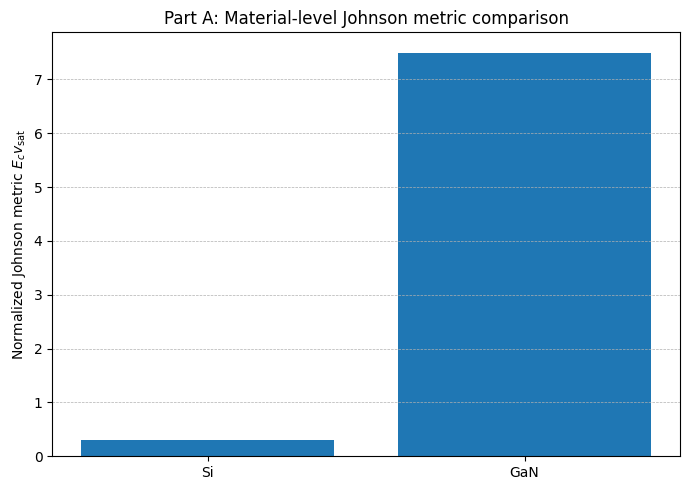

Normalized Johnson metric for Si  = 0.30
Normalized Johnson metric for GaN = 7.50
Ratio GaN / Si = 25.00


In [11]:

# Subtask 6.1.2 Plot the normalized Johnson material metric E_c * v_sat for Si and GaN.

materials = ['Si', 'GaN']
BVfT_metric = [Ec_Si * vsat_Si, Ec_GaN * vsat_GaN]

plt.figure(figsize=(7, 5))
plt.bar(materials, BVfT_metric)
plt.ylabel(r'Normalized Johnson metric $E_c v_{\mathrm{sat}}$')
plt.title('Part A: Material-level Johnson metric comparison')
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"Normalized Johnson metric for Si  = {BVfT_metric[0]:.2f}")
print(f"Normalized Johnson metric for GaN = {BVfT_metric[1]:.2f}")
print(f"Ratio GaN / Si = {BVfT_metric[1] / BVfT_metric[0]:.2f}")


In [12]:

# Subtask 6.1.3 Create functions for R_on(Wg), Q_g(Wg), and the losses.

def calc_Ron(Wg_val):
    return 0.18 / Wg_val              # ohm


def calc_Qg(Wg_val):
    return 6e-9 * Wg_val              # Coulomb


def calc_Pcond(Wg_val, I_val=I, D_val=D):
    return I_val**2 * D_val * calc_Ron(Wg_val)


def calc_Pgate(Wg_val, fs_val, Vdrv_val=Vdrv):
    return calc_Qg(Wg_val) * Vdrv_val * fs_val


def calc_Ptot(Wg_val, fs_val, I_val=I, D_val=D, Vdrv_val=Vdrv):
    return calc_Pcond(Wg_val, I_val, D_val) + calc_Pgate(Wg_val, fs_val, Vdrv_val)


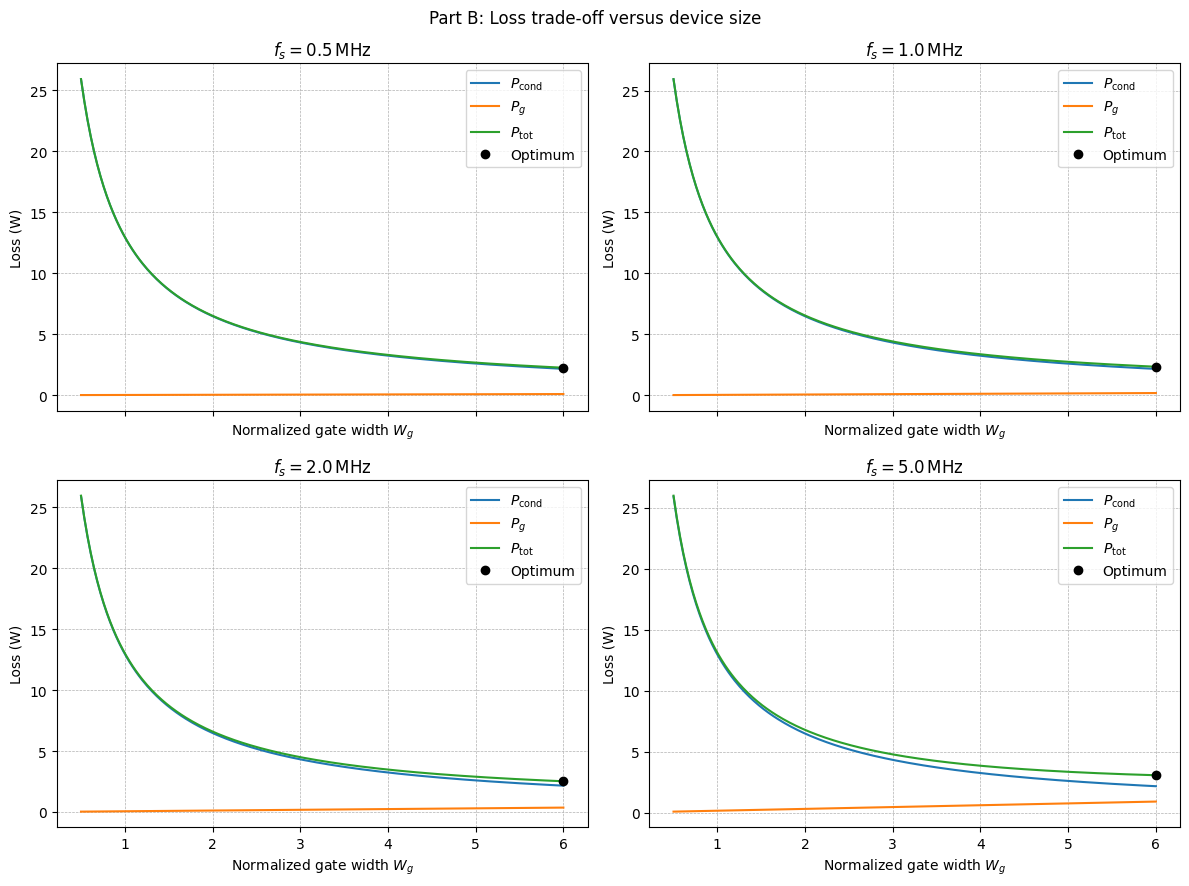

In [13]:

# Subtask 6.1.4 Plot P_cond, P_g, and P_tot versus Wg for the four frequencies.

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=False)
axes = axes.ravel()

opt_results = []

for idx, fs in enumerate(fs_list):
    ax = axes[idx]
    Pcond = calc_Pcond(Wg)
    Pgate = calc_Pgate(Wg, fs)
    Ptot = calc_Ptot(Wg, fs)

    ax.plot(Wg, Pcond, label=r'$P_{\mathrm{cond}}$')
    ax.plot(Wg, Pgate, label=r'$P_g$')
    ax.plot(Wg, Ptot, label=r'$P_{\mathrm{tot}}$')

    min_idx = np.argmin(Ptot)
    opt_Wg = Wg[min_idx]
    opt_P = Ptot[min_idx]
    opt_results.append((fs, opt_Wg, opt_P))

    ax.plot(opt_Wg, opt_P, 'ko', label='Optimum')
    ax.set_title(rf'$f_s = {fs/1e6:.1f}\,\mathrm{{MHz}}$')
    ax.set_xlabel(r'Normalized gate width $W_g$')
    ax.set_ylabel('Loss (W)')
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend()

plt.suptitle('Part B: Loss trade-off versus device size')
plt.tight_layout()
plt.show()



### Interpretation for Task 6.1

- The normalized Johnson metric is much larger for GaN than for Si.
- At low frequency, the total loss is dominated more by conduction loss, so larger devices are favored.
- As switching frequency increases, gate-drive loss becomes more important, so the optimum shifts toward smaller devices.
- This captures the lecture message that GaN is especially attractive for MHz converters, but device size must still be optimized rather than simply maximized.


In [14]:

# Subtask 6.1.5 Print the approximate optimum Wg for each switching frequency.

for fs, opt_Wg, opt_P in opt_results:
    print(f"f_s = {fs/1e6:.1f} MHz -> optimum W_g ≈ {opt_Wg:.2f}, minimum total loss ≈ {opt_P:.3f} W")


f_s = 0.5 MHz -> optimum W_g ≈ 6.00, minimum total loss ≈ 2.250 W
f_s = 1.0 MHz -> optimum W_g ≈ 6.00, minimum total loss ≈ 2.340 W
f_s = 2.0 MHz -> optimum W_g ≈ 6.00, minimum total loss ≈ 2.520 W
f_s = 5.0 MHz -> optimum W_g ≈ 6.00, minimum total loss ≈ 3.060 W



## 6.2. GaN electrical characteristics and dead-time behavior

This task illustrates that GaN device behavior cannot be judged from $R_{\mathrm{DS(on)}}$ alone. Blocking voltage, leakage, threshold voltage, temperature, capacitances, and reverse conduction all matter.

### Fixed values for this tutorial
Use a hypothetical enhancement-mode GaN HEMT with:
- $R_{\mathrm{DS(on)}}(25^\circ\mathrm{C}) = 35~\mathrm{m\Omega}$
- normalized temperature factor:
$$R_{\mathrm{norm}}(T_j)=1+0.004(T_j-25)$$
- full enhancement at $V_{GS}=5~\mathrm{V}$
- partial enhancement model:
  - at $V_{GS}=3~\mathrm{V}$, effective $R_{\mathrm{DS(on)}} = 1.6\times$ the fully enhanced value
  - at $V_{GS}=0~\mathrm{V}$, reverse conduction needs an added channel re-establishment drop of $2.5~\mathrm{V}$

Half-bridge conditions:
- current during dead time: $I = 10~\mathrm{A}$
- dead time per event: $t_d = 20~\mathrm{ns}$
- switching frequency: $f_s = 500~\mathrm{kHz}$

### Student tasks
6.2.1 Define the constants and create a function for $R_{\mathrm{DS(on)}}(T_j)$.

6.2.2 Plot $R_{\mathrm{DS(on)}}(T_j)$ from $25^\circ\mathrm{C}$ to $150^\circ\mathrm{C}$.

6.2.3 Compute conduction loss at $10~\mathrm{A}$ for $T_j = 25^\circ\mathrm{C}, 100^\circ\mathrm{C}, 150^\circ\mathrm{C}$.

6.2.4 Compare the effective reverse-conduction drop during dead time for:
- gate actively driven ON,
- gate held OFF.

6.2.5 Estimate dead-time energy per event
$$E_{dt} = V_{rev} I t_d$$
and average dead-time loss
$$P_{dt} = E_{dt} f_s$$
for both cases.

6.2.6 Explain why GaN can have nearly zero reverse-recovery charge and still suffer from significant dead-time loss.


In [ ]:

# Subtask 6.2.1 Define constants and create a function for R_DS(on)(Tj).

Rds25 = 35e-3   # ohm at 25°C
I_dt = 10.0     # A
I_cond = 10.0   # A
f_sw = 500e3    # Hz
Td = 20e-9      # s

Tj = np.linspace(25, 150, 300)
T_points = np.array([25, 100, 150])


def calc_Rds_T(Tj_val):
    return Rds25 * (1 + 0.004 * (Tj_val - 25))


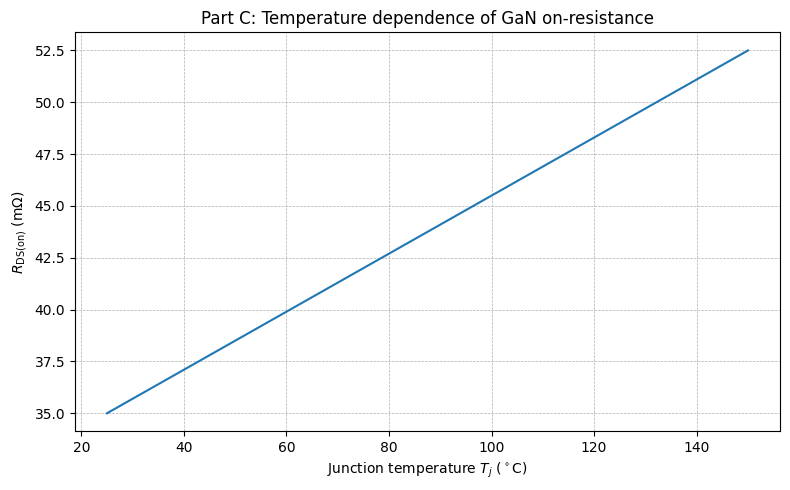

In [ ]:

# Subtask 6.2.2 Plot R_DS(on)(Tj) from 25°C to 150°C.

Rds_T = calc_Rds_T(Tj)

plt.figure(figsize=(8, 5))
plt.plot(Tj, Rds_T * 1e3)
plt.xlabel(r'Junction temperature $T_j$ ($^\circ$C)')
plt.ylabel(r'$R_{\mathrm{DS(on)}}$ (m$\Omega$)')
plt.title('Part C: Temperature dependence of GaN on-resistance')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [17]:

# Subtask 6.2.3 Compute conduction loss at 10 A for 25°C, 100°C, and 150°C.

for T in T_points:
    Ract = calc_Rds_T(T)
    Pcond = I_cond**2 * Ract
    print(f"Tj = {T:3.0f} °C -> R_DS(on) = {Ract*1e3:6.2f} mΩ, P_cond = {Pcond:5.2f} W")


Tj =  25 °C -> R_DS(on) =  35.00 mΩ, P_cond =  3.50 W
Tj = 100 °C -> R_DS(on) =  45.50 mΩ, P_cond =  4.55 W
Tj = 150 °C -> R_DS(on) =  52.50 mΩ, P_cond =  5.25 W


In [18]:

# Subtask 6.2.4 and 6.2.5 Compare reverse conduction drop and dead-time loss.

# Case 1: gate actively driven ON during reverse conduction
R_on_25 = calc_Rds_T(25)
Vrev_on = I_dt * R_on_25

# Case 2: gate held OFF, with added channel re-establishment drop
Vrev_off = 2.5 + I_dt * R_on_25

Edt_on = Vrev_on * I_dt * Td
Edt_off = Vrev_off * I_dt * Td

Pdt_on = Edt_on * f_sw
Pdt_off = Edt_off * f_sw

print(f"Actively driven ON: V_rev = {Vrev_on:.3f} V, E_dt = {Edt_on*1e9:.3f} nJ, P_dt = {Pdt_on*1e3:.3f} mW")
print(f"Gate held OFF:      V_rev = {Vrev_off:.3f} V, E_dt = {Edt_off*1e9:.3f} nJ, P_dt = {Pdt_off*1e3:.3f} mW")


Actively driven ON: V_rev = 0.350 V, E_dt = 70.000 nJ, P_dt = 35.000 mW
Gate held OFF:      V_rev = 2.850 V, E_dt = 570.000 nJ, P_dt = 285.000 mW



### Interpretation for Task 6.2

- $R_{\mathrm{DS(on)}}$ rises significantly with junction temperature, so static loss increases even in GaN devices.
- If the gate is actively driven ON during reverse conduction, the reverse drop is mainly the resistive channel drop.
- If the gate is held OFF, an additional reverse-conduction drop appears, which increases dead-time loss.
- GaN can have nearly zero classical reverse-recovery charge because reverse conduction is channel-based, not body-diode-based as in a Si MOSFET. However, dead-time loss can still be significant because the reverse drop during dead time may be large when the channel is not properly restored.
